In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import get_scorer
import gc
import gc
import os

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, make_scorer
)

# 1. Setup Data
expression_matrix=pd.read_table(r"D:\Dissertation\GDC TCGA Colon Cancer (COAD)\TCGA-COAD.star_counts_raw.tsv", index_col=0)
extracted_biomarkers=pd.read_csv(r"D:\Mcode final__COAD\output\extracted_biomarkers.csv")
metadata = pd.read_csv(r"D:\Mcode final__COAD\data\metadata.csv", index_col=0)

raw = expression_matrix
df_biomarkers = pd.read_csv('biomarker_results_COAD.csv')



y = (metadata['Status'] == 'Tumor').astype(int).tolist()

# Define Gene Sets
methods_genes = {
    "HR-FRGS": extracted_biomarkers['Gene_Symbol'].tolist(),
    "WGCNA-PPI": df_biomarkers[df_biomarkers['Method1_WGCNA_PPI']==1]['gene'].tolist(),
    "ML-Ensemble": df_biomarkers[df_biomarkers['Method2_ML_Ensemble']==1]['gene'].tolist(),
    "MCODE-Module": df_biomarkers[df_biomarkers['Method3_MCODE']==1]['gene'].tolist()
}

probemap = pd.read_table(r"D:\Mcode final__LUAD\data\gencode.v36.annotation.gtf.gene.probemap")
        
# Capture the specific name of your Ensembl ID column (e.g., 'id' or 'index')
ensembl_col_name = raw.index.name if raw.index.name else 'index'
        
# Merge: 'id' (Ensembl) matches count matrix index; 'gene' is the Symbol
raw = raw.reset_index().merge(probemap[['id', 'gene']], 
                                    left_on=ensembl_col_name, 
                                    right_on='id')
        
# Set index to gene symbol and explicitly drop BOTH Ensembl ID columns
# 'id' is from the probemap, and ensembl_col_name is from your original matrix
raw = raw.set_index('gene').drop([ensembl_col_name, 'id'], axis=1, errors='ignore')

print(raw.head())

X_full=raw.T.astype(np.float32)

          TCGA-5M-AAT6-01A  TCGA-AA-3552-01A  TCGA-AA-3867-01A  \
gene                                                             
TSPAN6                1213              4178              5224   
TNMD                     4                 7                 2   
DPM1                  1234               847              1212   
SCYL3                  363               242               231   
C1orf112               325               112               133   

          TCGA-AD-6895-01A  TCGA-AA-3560-01A  TCGA-CM-6676-01A  \
gene                                                             
TSPAN6                 795              3758             11754   
TNMD                     0                39               389   
DPM1                  1510               451              4817   
SCYL3                  569               199               634   
C1orf112               285               195               392   

          TCGA-AA-A029-01A  TCGA-AA-A01C-01A  TCGA-CK-5912-01A  \
gene    

In [55]:
print(X_full.columns)

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'AL451106.1', 'AC092910.4', 'AC073611.1', 'AC136977.1', 'AC078856.1',
       'AC008763.4', 'AL592295.6', 'AC006486.3', 'AL391628.1', 'AP006621.6'],
      dtype='object', name='gene', length=60660)


In [56]:
# Define Models & Metrics
classifiers = {
    "SVM": SVC(probability=True, kernel='linear',max_iter=20000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

scoring = {
    'AUC': 'roc_auc',
    'Recall': 'recall',
    'Precision': 'precision',
    'Accuracy': 'accuracy',
    'F1-score': 'f1',
    'MCC': make_scorer(matthews_corrcoef)
}

# 2. Run Cross-Validation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
all_results = []

for method_name, genes in methods_genes.items():
    valid_genes = [g for g in genes if g in X_full.columns]
    X_sub = X_full[valid_genes]
    print("Running Dataset",method_name,len(valid_genes))
    
    for clf_name, clf in classifiers.items():
        print("Running Classifier",clf_name)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    clf),
        ])

        cv_results = cross_validate(pipeline, X_sub, y, cv=cv, scoring=scoring, n_jobs=-1)
        for i in range(len(cv_results['test_Accuracy'])):
            for metric in scoring.keys():
                all_results.append({
                    "Method": method_name,
                    "Classifier": clf_name,
                    "Metric": metric,
                    "Score": cv_results[f'test_{metric}'][i]
                })

df_metrics = pd.DataFrame(all_results)

# 3. Calculate Summary using Mean and Variance
# We use .var() for variance calculation
summary = df_metrics.groupby([ 'Classifier','Method', 'Metric'])['Score'].agg(['mean', 'var']).reset_index().sort_values( 'Classifier')

# Formatting to 4 decimal places (variance is often small, so 4 decimals is better)
summary['Result'] = summary.apply(lambda x: f"{x['mean']:.4f} ± {x['var']:.4f}", axis=1)

# Pivot for a clean table
pivot_summary = summary.pivot_table(index=['Method', 'Classifier'], 
                                    columns='Metric', 
                                    values='Result', 
                                    aggfunc='first').sort_values( 'Classifier')

print("\n--- Final Performance Summary (Mean ± Variance) ---")
print(pivot_summary)

# 4. Final Visualization (Boxplot stays the same as it shows raw distribution)
# plt.figure(figsize=(15, 10))
# ... (same plotting code as provided in previous turn)

Running Dataset HR-FRGS 172
Running Classifier SVM
Running Classifier Random Forest
Running Classifier XGBoost
Running Dataset WGCNA-PPI 10
Running Classifier SVM
Running Classifier Random Forest
Running Classifier XGBoost
Running Dataset ML-Ensemble 4
Running Classifier SVM
Running Classifier Random Forest
Running Classifier XGBoost
Running Dataset MCODE-Module 321
Running Classifier SVM
Running Classifier Random Forest
Running Classifier XGBoost

--- Final Performance Summary (Mean ± Variance) ---
Metric                                  AUC         Accuracy         F1-score  \
Method       Classifier                                                         
HR-FRGS      Random Forest  0.9998 ± 0.0000  0.9961 ± 0.0001  0.9979 ± 0.0000   
MCODE-Module Random Forest  1.0000 ± 0.0000  0.9975 ± 0.0000  0.9986 ± 0.0000   
ML-Ensemble  Random Forest  0.9927 ± 0.0002  0.9862 ± 0.0001  0.9925 ± 0.0000   
WGCNA-PPI    Random Forest  0.9027 ± 0.0024  0.9411 ± 0.0002  0.9690 ± 0.0001   
HR-FRGS  

In [57]:
pivot_summary.to_csv('performance_comparison_COAD.csv')

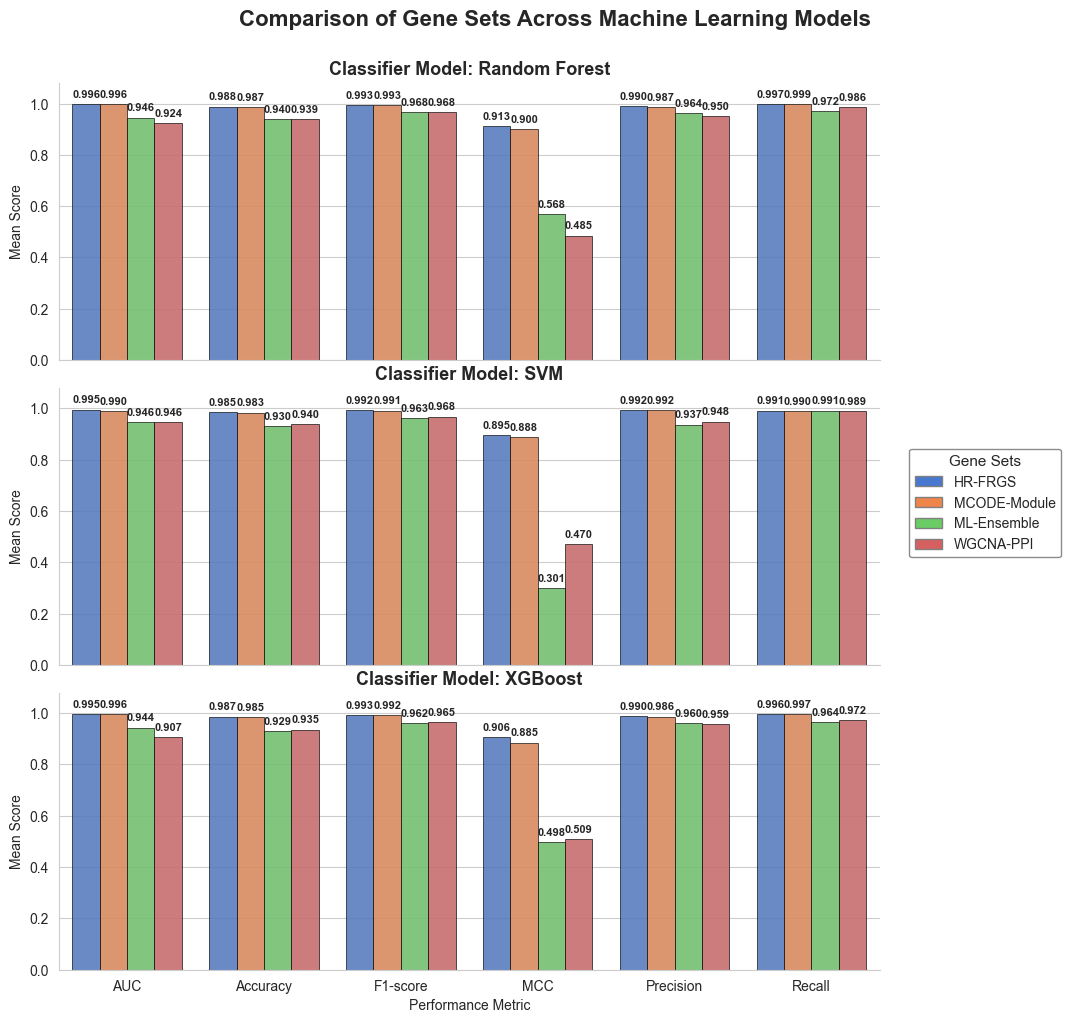

In [62]:
# 1. Load the performance comparison data
df = pd.read_csv('performance_comparison_HNSC.csv')

def extract_mean(val):
    if isinstance(val, str) and ' ± ' in val:
        return float(val.split(' ± ')[0])
    return val

metric_cols = ['AUC', 'Accuracy', 'F1-score', 'MCC', 'Precision', 'Recall']
for col in metric_cols:
    df[col] = df[col].apply(extract_mean)

df_melted = df.melt(id_vars=['Method', 'Classifier'], 
                    value_vars=metric_cols, 
                    var_name='Metric', 
                    value_name='Mean Score')

# 2. Get unique methods and assign colors BEFORE plotting
methods = df_melted['Method'].unique().tolist()
palette = sns.color_palette("muted", n_colors=len(methods))
color_map = dict(zip(methods, palette))

# 3. Create the Figure — reduced height, tighter aspect
sns.set_style("whitegrid")
g = sns.catplot(
    data=df_melted, kind="bar",
    x="Metric", y="Mean Score", hue="Method",
    col="Classifier", col_wrap=1,
    palette=color_map,
    alpha=0.9,
    height=3.5,        # ← slightly shorter per subplot
    aspect=3.2,        # ← a bit wider to spread bars
    edgecolor="black", linewidth=0.5,
    legend=False
)

# 4. Annotate bars
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.3f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 7), 
                        textcoords='offset points',
                        fontsize=8.0, fontweight='bold')
    
    # Tighten y-axis: start from 0, add small headroom for annotations
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))

# 5. Axis labels and subplot titles
g.set_axis_labels("Performance Metric", "Mean Score")
g.set_titles("Classifier Model: {col_name}", fontweight='bold', size=13)

# 6. Build legend handles directly from color_map
import matplotlib.patches as mpatches
handles = [mpatches.Patch(facecolor=color_map[m], label=m, edgecolor='gray') 
           for m in methods]

# 7. Tight spacing — key change: hspace reduced to 0.08
g.fig.subplots_adjust(top=0.9, right=0.79, hspace=0.1)
g.fig.suptitle("Comparison of Gene Sets Across Machine Learning Models",
               y=0.97, fontsize=16, fontweight='bold')

# 8. Figure-level legend in right margin, vertically centered
g.fig.legend(
    handles=handles,
    title="Gene Sets",
    loc="center left",
    bbox_to_anchor=(0.81, 0.5),
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor="gray"
)

# 9. Remove x-axis labels from all but the bottom subplot to save space
for ax in g.axes.flat[:-1]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)   # hide x tick labels on upper panels



# Save high-resolution figure
# plt.tight_layout()
plt.savefig("model_by_model_comparison_HNSC.png", dpi=600, bbox_inches='tight')
plt.show()

